In [20]:
#This example will highlight the find cluster tool by inputting right ascension and declination coordinates of the cluster as well as plot the cluster


In [21]:
#We will start by importing the gaia input module and the mean photometry module. We will query the data and then plot the cluster
import os
os.chdir("C:/Users/nakia/OneDrive/Documents/GitHub/gaiadr3-analysis")
import gaiadr3_analysis.gaia_input as gi
import gaiadr3_analysis.mean_photometry as mphot

In [36]:
#This is optional but logging into Gaia Archive using credentials may resolve any access issues when querying
gi.gaia_login_prompt()

INFO: Login to gaia TAP server [astroquery.gaia.core]
INFO: OK [astroquery.utils.tap.core]
INFO: Login to gaia data server [astroquery.gaia.core]
INFO: OK [astroquery.utils.tap.core]
Logged in to Gaia archive.


In [37]:
#now calling the function and putting the coordinates for the IC 2602 cluster for reference. The function should find the closest cluster which in this case should show IC 2602
gi.find_cluster(ra = 160.8, dec = -64.4, distance = 152)

#Below should be printed the name of the closest cluster found nearby these coordinates

'IC 2602'

In [38]:
#Now our goal is to take the information from the find_cluster and pull actual data for the stars that form the cluster
#We can do this using the resolve ID function, we have the found cluster name and now we use this identifier to query the data for the cluster.

cluster_ID = gi.resolve_id("IC 2602")

id_list = ", ".join(str(s) for s in cluster_ID)

adql = f"""
SELECT source_id, designation, ra, dec, parallax,
pmra, pmdec, phot_g_mean_mag, phot_bp_mean_mag,
phot_rp_mean_mag
FROM gaiadr3.gaia_source
WHERE source_id IN ({id_list})
"""

df = gi.query_by_adql(adql)
print(f"Retrieved {len(df)} stars")
df.head()


Retrieved 2000 stars


,source_id,designation,ra,dec,parallax,pmra,pmdec,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag
0,5226406515506594560,Gaia DR3 5226406515506594560,165.839437,-72.787399,5.913695,-17.615244,11.082608,11.689121,12.131037,11.060328
1,5234867944690161024,Gaia DR3 5234867944690161024,168.259779,-68.123589,7.924953,-24.372118,12.462855,16.990017,19.111473,15.649081
2,5238048969264890880,Gaia DR3 5238048969264890880,163.159436,-67.985160,7.731530,-22.165607,12.408636,14.637488,16.068993,13.460412
3,5239296983687031680,Gaia DR3 5239296983687031680,160.168655,-65.600360,0.205049,-6.115413,2.827334,14.383759,15.095569,13.559880
4,5239594813911457024,Gaia DR3 5239594813911457024,162.200439,-64.979901,0.453067,-11.343677,5.973941,13.188563,14.043778,12.275602


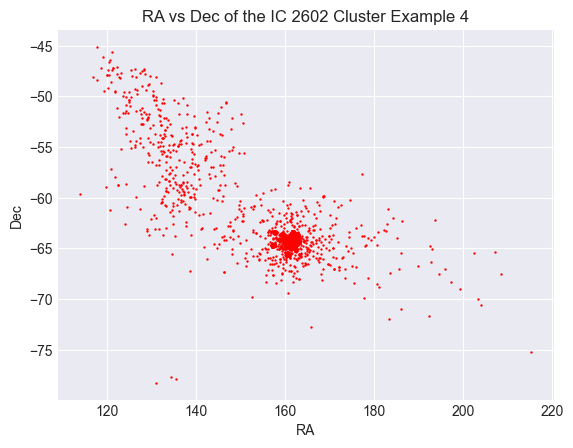

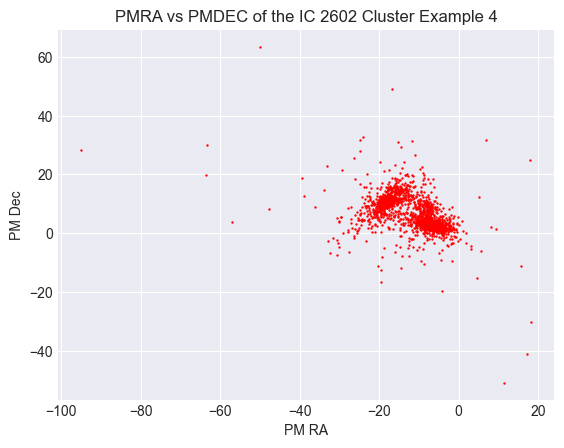

C:\Users\nakia\OneDrive\Documents\GitHub\gaiadr3-analysis\gaiadr3_analysis\mean_photometry.py:169: RuntimeWarning: invalid value encountered in log10
  return phot_g_mean_mag - 5 * np.log10(distance / 10)


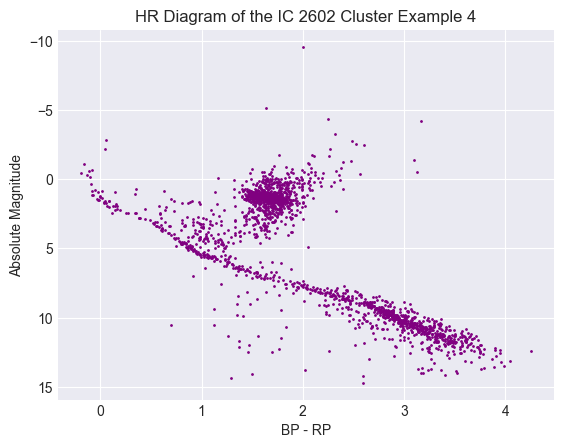

Distance, meidian: 754.7932868752032


C:\Users\nakia\OneDrive\Documents\GitHub\gaiadr3-analysis\gaiadr3_analysis\mean_photometry.py:316: OptimizeWarning: Covariance of the parameters could not be estimated
  fit = curve_fit(gaussian, x_1d_fit, y_1d_fit, p0 = [55, std, median])


Standard Deviation: 10833.721374571207


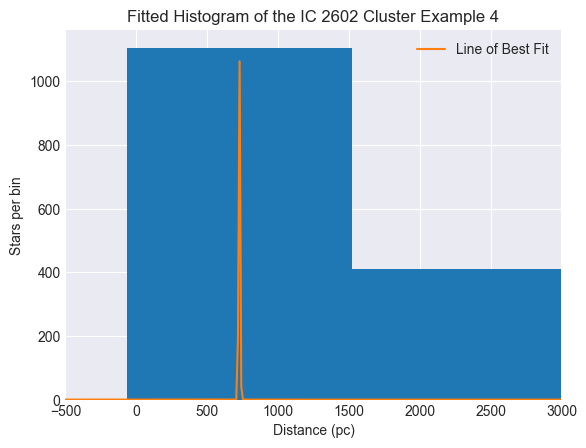

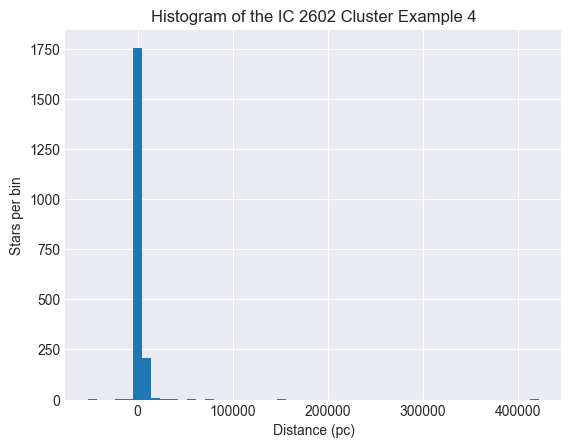

In [46]:
#Now the data will be used to plot simple functions in our mean photometry module. 
#We won't be saving the plots in this example, but if wanted, the save_plot parameter can be set to True and a file_name and save_folder can be given to save the plots with a specific name and in a specific folder.


#Each function, as seen below, is called using the mean_photometry module as mphot. Although is can be imported as any variable. Then the function is written in the form of modname.function_name(parameters)

mphot.ra_vs_dec(df, title = "RA vs Dec of the IC 2602 Cluster Example 4")
mphot.pmra_vs_pmdec(df, title = "PMRA vs PMDEC of the IC 2602 Cluster Example 4")
mphot.plot_hr_diagram(df, title = "HR Diagram of the IC 2602 Cluster Example 4")
mphot.fittedHist(dists=df['parallax'], parallax=True, title = "Fitted Histogram of the IC 2602 Cluster Example 4", bin_num = 300, range = [-500, 3000])
mphot.hist(dists=df['parallax'], parallax=True, title = "Histogram of the IC 2602 Cluster Example 4")
